In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split


plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

In [10]:
df = pd.read_csv("data/BostonHousing.csv")

In [ ]:
print("Primeiras linhas:")
df.head()

Primeiras linhas:


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [ ]:
print("Informações do Dataset:")
df.info()

Informações gerais:
<class 'pandas.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       501 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  b        506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


In [15]:
print("Estatisticas")
df.describe()

Estatisticas


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
count,506.000000,506.000000,506.000000,506.000000,506.000000,501.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284341,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.705587,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.884000,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208000,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.625000,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [17]:
print("Valores Nulos:")
df.isnull().sum()

Valores Nulos:


crim       0
zn         0
indus      0
chas       0
nox        0
rm         5
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
medv       0
dtype: int64

In [26]:
df["rm"] = df["rm"].fillna(df["rm"].median())
#Foram identificados 5 valores nulos na coluna "rm", para evitar perda de dados decidi substituir os valores nulos pela mediana da 
#coluna.

In [27]:
df["rm"].isnull().sum()

np.int64(0)

In [28]:
df.isnull().sum()

crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
medv       0
dtype: int64

Entendendo o DataSet
O dataset Boston Housing indica fatores que influenciam o preço das casas em Boston.

variável alvo é "medv" (valor médio das casas), e as variáveis preditoras são:

crim: taxa de criminalidade per capita

zn: Porcentagem de terrenos com lotes grandes.

indus: Porcentagem de area industrial.

chas: Se é próximo ao rio Charles (1) ou não (0).

nox: Poluição do ar.

rm: Número médio de quartos por casa.

age: porcentagem de casas antigas. Quando muito alto indica regiões mais antigas.

dis: Distância para os centros de emprego.

rad: Índice de acessibilidade às rodovias.

tax: Taxa de imposto sobre a propriedade.

ptratio: Índice de alunos por professor. Alto pode indicar pior educação.

b: Demografia.

lstat: Porcentagem da população de baixa renda.

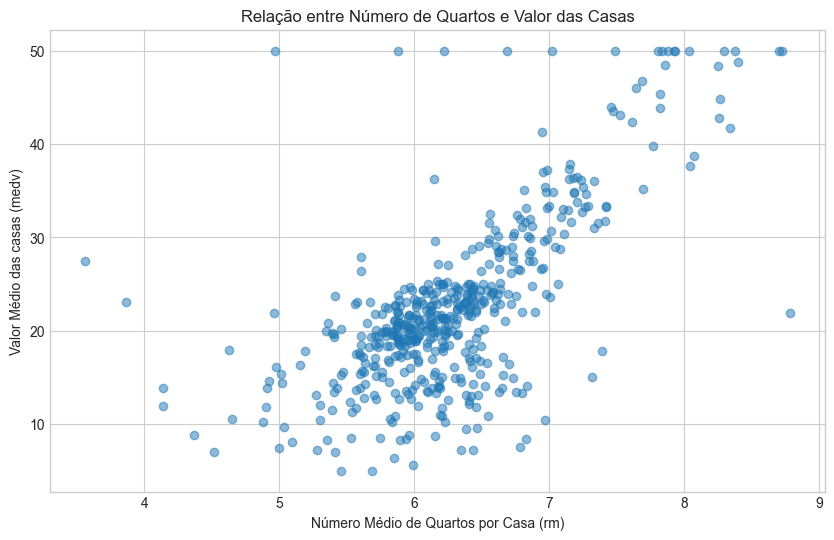

In [33]:
plt.figure(figsize=(10, 6))
plt.scatter(df["rm"], df["medv"], alpha=0.5)
plt.title("Relação entre Número de Quartos e Valor das Casas")
plt.xlabel("Número Médio de Quartos por Casa (rm)")
plt.ylabel("Valor Médio das casas (medv)")
plt.show()

Ao analisarmos o gráfico, observa-se que o número de quartos influencia diretamente no preço das casas na maioria dos casos, porém algumas casas mesmo com grande número de quartos, seu preço ainda é baixo. Isso pode ser influência de outros fatores que vamos analisar. 

In [36]:
casas_com_estranha_relacao = df[(df["rm"] > 6) & (df["medv"] < 20)]
casas_com_estranha_relacao.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
9,0.17004,12.5,7.87,0,0.524,6.004,85.9,6.5921,5,311,15.2,386.71,17.10,18.9
10,0.22489,12.5,7.87,0,0.524,6.208,94.3,6.3467,5,311,15.2,392.52,20.45,15.0
11,0.11747,12.5,7.87,0,0.524,6.009,82.9,6.2267,5,311,15.2,396.90,13.27,18.9
14,0.63796,0.0,8.14,0,0.538,6.096,84.5,4.4619,4,307,21.0,380.02,10.26,18.2
22,1.23247,0.0,8.14,0,0.538,6.142,91.7,3.9769,4,307,21.0,396.90,18.72,15.2


In [38]:
casas_com_normal_relacao = df[(df["rm"] > 6) & (df["medv"] >= 20)]
casas_com_normal_relacao.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [42]:
comparacao = pd.DataFrame({
    "Estranhas": casas_com_estranha_relacao.mean(),
    "Normais": casas_com_normal_relacao.mean()
})
comparacao

,Estranhas,Normais
crim,7.202455,0.750253
zn,0.788043,20.264463
indus,15.656087,7.531364
chas,0.032609,0.086777
nox,0.640825,0.496471
rm,6.339402,6.732004
age,89.984783,54.960744
dis,2.643289,4.607209
rad,16.478261,6.115702
tax,552.445652,327.194215


Por essa comparação, observa-se que as casas com mais quartos e com menor preço são influenciadas por fatores como criminalidade
(crim) que é muito alta nas estranhas.

Porcentagem de terrenos grandes (zn) que nas normais é muito maior que nas estranhas.

Porcentagem de zona indústrial (indus) que é muito maior nas estranhas.

Proximidade do Rio (chas) as estranhas são mais longr do rio.

Poluição do ar (nox) que é maior nas estranhas.

A idade da região (age) que é muito maior nas estranhas, esse fator deve influenciar muito.

Na distância dos centros de emprego (dis) percebemos que as estranhas são mais próximas dos centros e mesmo assim seu valor é baixo, indicando que nem sempre ser próximo do centro influencia tanto no preço se os outros fatores serem prejudiciais.
A mesma coisa acontece na acessibilidade das rodovias (rad).

A taxa de imposto (tax) é bem maior nas casas estranhas. Isso influencia muito.

Nas estranhas a educação é pior, como indica o indice de alunos por professor (ptratio)

Nas estranhas a porcentagem de população de baixa renda é bem maior, podemos dizer que esse fator é uma consequência de todos os outros que vimos até aqui.



In [51]:
x = df.drop("medv", axis=1)
y = df["medv"]

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)
model = LinearRegression()
model.fit(x_train, y_train)

y_pred = model.predict(x_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

for nome, coef in zip(x.columns, model.coef_):
    print(f"{nome}: {coef:.2f}")
print(f'Intercepto: {model.intercept_:.2f}')
print(f'MAE: {mae:.2f}')
print(f'R2: {r2:.2f}')


crim: -0.11
zn: 0.03
indus: 0.04
chas: 2.78
nox: -17.21
rm: 4.44
age: -0.01
dis: -1.44
rad: 0.26
tax: -0.01
ptratio: -0.92
b: 0.01
lstat: -0.51
Intercepto: 30.21
MAE: 3.21
R2: 0.67


Acima temos a avaliação do modelo.

In [56]:
nova_casa = x_test.iloc[0]

previsao = model.predict([nova_casa])

print(f"Valor real: {y_test.iloc[0]:.2f}")
print(f"Valor previsto: {previsao[0]:.2f}")

Valor real: 23.60
Valor previsto: 28.99


c:\Users\vitor\OneDrive\Área de Trabalho\Analises\boston_housing_analise\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [62]:
for i in range(5):
    print(f"Real: {y_test.iloc[i]:.2f}")
    print(f"Previsto: {model.predict([x_test.iloc[i]])[0]:.2f}")
    print("-------------------------")

Real: 23.60
Previsto: 28.99
-------------------------
Real: 32.40
Previsto: 36.01
-------------------------
Real: 13.60
Previsto: 14.84
-------------------------
Real: 22.80
Previsto: 25.02
-------------------------
Real: 16.10
Previsto: 18.77
-------------------------


c:\Users\vitor\OneDrive\Área de Trabalho\Analises\boston_housing_analise\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\vitor\OneDrive\Área de Trabalho\Analises\boston_housing_analise\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\vitor\OneDrive\Área de Trabalho\Analises\boston_housing_analise\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\vitor\OneDrive\Área de Trabalho\Analises\boston_housing_analise\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\U

Ao comparar os valores reais com os previstos, observa-se que o modelo apresenta boa capacidade de aproximação, porém com tendência à superestimação dos preços. Em diversos casos, os valores previstos são superiores aos reais, indicando que o modelo pode estar atribuindo peso elevado a variáveis positivas, como o número de quartos, sem capturar completamente fatores que reduzem o valor das casas.

In [63]:
erros = y_test - y_pred
for i in range(5):
    print(f"Real: {y_test.iloc[i]:.2f}")
    print(f"Previsto: {y_pred[i]:.2f}")
    print(f"Erro: {erros.iloc[i]:.2f}")
    print("-------------------------")

Real: 23.60
Previsto: 28.99
Erro: -5.39
-------------------------
Real: 32.40
Previsto: 36.01
Erro: -3.61
-------------------------
Real: 13.60
Previsto: 14.84
Erro: -1.24
-------------------------
Real: 22.80
Previsto: 25.02
Erro: -2.22
-------------------------
Real: 16.10
Previsto: 18.77
Erro: -2.67
-------------------------


In [64]:
print("Erro médio:", erros.mean())
print("Erro absoluto médio:", abs(erros).mean())
print("Maior erro:", erros.max())
print("Menor erro:", erros.min())

Erro médio: 0.26050704034817934
Erro absoluto médio: 3.2114487155504934
Maior erro: 25.266788523927392
Menor erro: -10.936350346821463


In [75]:
erros_abs = abs(erros)

indices_maiores_erros = erros_abs.sort_values(ascending=False).head(5)

indices_maiores_erros

371    25.266789
412    18.060083
365    15.007048
414    13.082463
375    10.936350
Name: medv, dtype: float64

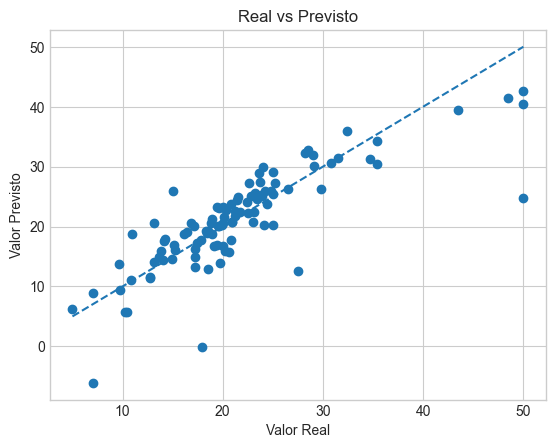

In [77]:
plt.scatter(y_test, y_pred)

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle="--")

plt.xlabel("Valor Real")
plt.ylabel("Valor Previsto")
plt.title("Real vs Previsto")
plt.show()

O gráfico de dispersão entre os valores reais e previstos demonstra a capacidade do modelo em aproximar os preços dos imóveis. Observa-se que grande parte dos pontos está próxima da linha diagonal, indicando que o modelo consegue capturar a tendência geral dos dados. No entanto, há uma dispersão considerável em alguns pontos, evidenciando erros de previsão, principalmente em valores mais extremos.

In [80]:
y_pred_series = pd.Series(y_pred, index=y_test.index)

comparacao = pd.DataFrame({
    "Real": y_test.loc[indices],
    "Previsto": y_pred_series.loc[indices],
    "Erro": erros.loc[indices]
})
comparacao

,Real,Previsto,Erro
371,50.0,24.733211,25.266789
412,17.9,-0.160083,18.060083
365,27.5,12.492952,15.007048
414,7.0,-6.082463,13.082463
375,15.0,25.936350,-10.936350


A análise dos erros indicou que o modelo apresenta erros moderados, com alguns casos de erro elevado. Observa-se uma tendência de superestimação dos valores, onde o modelo frequentemente prevê preços acima dos reais. Além disso, os maiores erros estão associados a imóveis com características atípicas, sugerindo que a regressão linear não consegue capturar totalmente relações mais complexas entre as variáveis.

In [82]:


from sklearn.ensemble import RandomForestRegressor


model_rf = RandomForestRegressor(random_state=42)
model_rf.fit(x_train, y_train)

y_pred_rf = model_rf.predict(x_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"MAE RF: {mae_rf:.2f}")
print(f"R2 RF: {r2_rf:.2f}")

MAE RF: 2.06
R2 RF: 0.89


Inicialmente, foi utilizado um modelo de regressão linear, que apresentou desempenho moderado, com R² de 0.67 e erro médio absoluto de 3.21. No entanto, ao aplicar o modelo Random Forest, observou-se uma melhoria significativa, com R² de 0.89 e MAE de 2.06.

Essa melhoria evidencia que o problema possui relações não lineares entre as variáveis, as quais não são bem capturadas pela regressão linear. O Random Forest, por sua capacidade de modelar interações complexas e lidar melhor com outliers, demonstrou ser mais adequado para a previsão de preços de imóveis neste contexto.

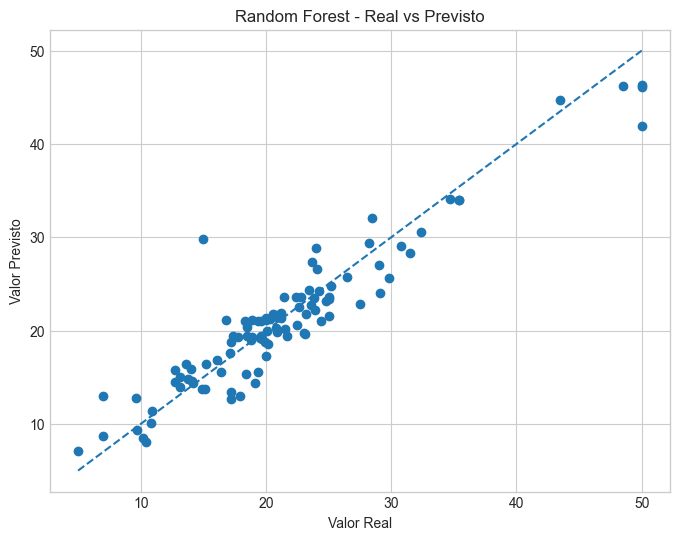

In [83]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred_rf)


plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Valor Real")
plt.ylabel("Valor Previsto")
plt.title("Random Forest - Real vs Previsto")

plt.show()

In [84]:
import joblib

joblib.dump(model_rf, "modelo.pkl")

['modelo.pkl']